# 项目 2：深度探索性数据分析 (EDA)

## Netflix 内容分析 🎬

**项目目标：** 对 Netflix 数据集进行深度探索性数据分析。我们将探索内容制作趋势，识别热门类型，分析内容评级，并了解电影和电视节目在该平台上的分布情况。本项目以基础 EDA 为基础，引入时间序列分析以及更复杂的数据清洗和转换技术。

### 我们将涵盖的核心概念：

1. **数据清洗与转换：** 处理缺失值并转换数据类型（尤其是日期）。

2. **时间序列分析：** 分析 Netflix 多年来的内容添加情况。

3. **文本数据处理：** 解析和分析包含多个值的列，例如 `listed_in`（类型）和 `cast`。

4. **地理位置和评级分析：** 了解内容的来源及其成熟度级别。

5. **特征工程：** 创建新的、有洞察力的特征，例如“内容年龄”。

6. **高级可视化：** 创建有洞察力的图表，以了解数据的分布和关系。

### 第一步：设置 - 导入库

和往常一样，我们首先导入必要的数据科学工具集，其中包括一个新的词云库。

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os 
import sys 
os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))

# Set a consistent style for our plots
sns.set_style('darkgrid')

NameError: name '__file__' is not defined

### 第二步：数据加载和初步检查

我们将加载 `netflix_titles.csv` 数据集并进行概览

In [ ]:
# !git clone "https://github.com/HarshvardhanSingh-13/Datasets"

Cloning into 'Datasets'...
Updating files:  17% (42/245)
Updating files:  18% (45/245)
Updating files:  19% (47/245)
Updating files:  20% (49/245)
Updating files:  21% (52/245)
Updating files:  22% (54/245)
Updating files:  23% (57/245)
Updating files:  24% (59/245)
Updating files:  25% (62/245)
Updating files:  26% (64/245)
Updating files:  27% (67/245)
Updating files:  28% (69/245)
Updating files:  29% (72/245)
Updating files:  30% (74/245)
Updating files:  31% (76/245)
Updating files:  32% (79/245)
Updating files:  33% (81/245)
Updating files:  34% (84/245)
Updating files:  34% (85/245)
Updating files:  35% (86/245)
Updating files:  36% (89/245)
Updating files:  37% (91/245)
Updating files:  38% (94/245)
Updating files:  39% (96/245)
Updating files:  40% (98/245)
Updating files:  41% (101/245)
Updating files:  42% (103/245)
Updating files:  43% (106/245)
Updating files:  44% (108/245)
Updating files:  45% (111/245)
Updating files:  46% (113/245)
Updating files:  47% (116/245)
Updati

In [ ]:
netflix_df = pd.read_csv('../Datasets/Netflix_Titles Dataset/netflix_titles.csv')
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [ ]:
# Get a concise summary of the dataframe
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


**`.info()` 的解读：**

- 我们有 7787 条记录（标题）。

- **关键问题：** `date_added` 列的类型为 `object`（字符串），而非 `datetime` 对象。在更正此问题之前，我们无法进行基于时间的分析。

- **缺失值：** `director`、`cast`、`country`、`date_added` 和 `rating` 列均存在缺失值。其中，`director` 列的空值数量最多。

### 第三步：数据清洗和转换

这一步对于确保分析结果的准确性至关重要。我们将处理缺失值并纠正数据类型。

#### **理论概念：数据类型转换与空值处理**

数据通常以非理想格式存储。例如，将日期存储为字符串会妨碍我们提取年份或月份等组成部分，或绘制随时间变化的数据图。将列转换为正确的数据类型（`pd.to_datetime`、`.astype()`）是基本的预处理步骤。

对于空值，我们有以下几种策略：

1. **删除：** 如果只有极少数行存在缺失数据，则删除这些行是可以接受的（`.dropna()`）。

2. **填充/插补：** 将缺失值替换为占位符（例如“未知”）或统计量（例如分类数据的众数）。当您不想丢失这些行中的其他信息时，此方法非常有用。

In [ ]:
# 1. Handle missing values in 'director' and 'cast'
# Since these are text fields and many are missing, we'll fill them with 'Unknown'.
netflix_df['director'] = netflix_df['director'].fillna('Unknown')
netflix_df['cast'] = netflix_df['cast'].fillna('Unknown')

In [ ]:
# 2. Handle missing 'country'
# We'll fill with the mode, which is the most common country.
mode_country = netflix_df['country'].mode()[0]
netflix_df['country'] = netflix_df['country'].fillna(mode_country)

In [ ]:
# 3. Drop the few rows with missing 'date_added' and 'rating'
# Since the number is small (less than 0.2% of data), dropping them is a safe option.
netflix_df.dropna(subset=['date_added', 'rating'], inplace=True)

In [ ]:
# 4. Convert 'date_added' to datetime objects
# Use format='mixed' to handle potential variations in date formats
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'], format='mixed', dayfirst=False)

* **format='mixed':** 此参数指示 pandas 自动推断日期格式。当列中的日期字符串格式不同时，此功能非常有用。

* **dayfirst=False:** 此参数指定，当日期格式不明确时（例如，01/02/2023），应将其解释为月份在前（1月2日），而不是日期在前（2月1日）。

In [ ]:
# 5. Create new features for year and month added
netflix_df['year_added'] = netflix_df['date_added'].dt.year
netflix_df['month_added'] = netflix_df['date_added'].dt.month 

In [ ]:
# Verify our cleaning and transformation
print("Missing values after cleaning:")
print(netflix_df.isnull().sum())
print("\nData types after transformation:")
print(netflix_df.dtypes)

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

Data types after transformation:
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int32
month_added              int32
dtype: object


### 第四步：探索性数据分析与可视化

#### 4.1 内容类型的分布情况如何？

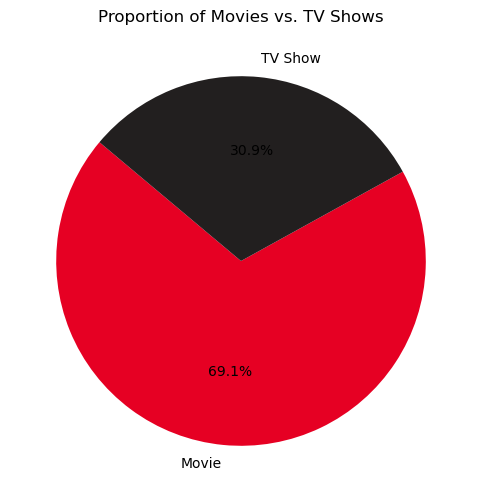

In [ ]:
plt.figure(figsize=(8, 6))
type_counts = netflix_df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=['#e60023', '#221f1f'])
plt.title('Proportion of Movies vs. TV Shows')
plt.ylabel('')
plt.show()

**洞察：** Netflix 的内容库以电影为主，约占该数据集内容的 70%。

#### 4.2 随着时间的推移，内容是如何增加的？

type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      0.0
2010           1.0      0.0
2011          13.0      0.0
2012           3.0      0.0
2013           6.0      5.0
2014          19.0      6.0
2015          58.0     30.0
2016         256.0    184.0
2017         861.0    361.0
2018        1255.0    429.0
2019        1497.0    656.0
2020        1312.0    697.0
2021          88.0     29.0


<Figure size 1400x800 with 0 Axes>

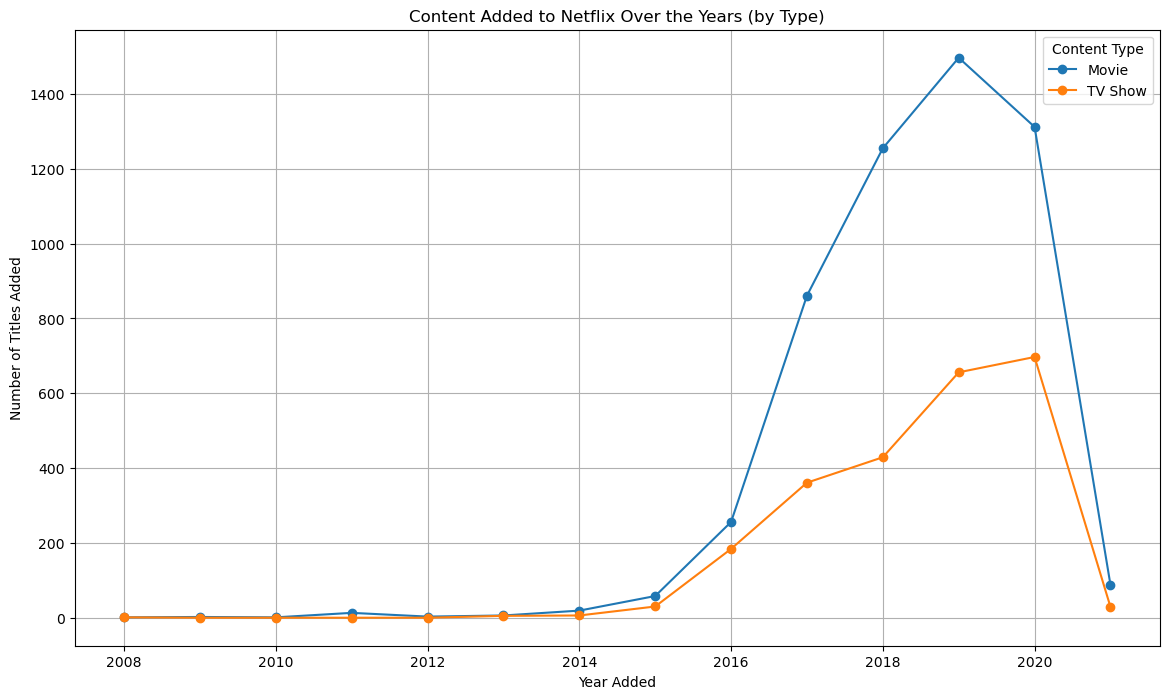

In [ ]:
# Group data by year and content type
content_over_time = netflix_df.groupby(['year_added', 'type']).size().unstack().fillna(0)
print(content_over_time)
plt.figure(figsize=(14, 8))
content_over_time.plot(kind='line', marker='o', figsize=(14, 8))
plt.title('Content Added to Netflix Over the Years (by Type)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

**洞察**:通过区分电影和电视剧，我们可以看到，虽然两者都实现了显著增长，但电影的增长速度更为迅猛，并在2019年达到顶峰。电视剧的增长则更为稳定。2020年和2021年的内容新增量似乎略有放缓，这可能是由于新冠疫情影响了影视制作，也可能是由于最新年份的数据集不完整。

In [ ]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12


#### 4.3 最受欢迎的类型有哪些？

#### **理论概念：处理多值文本列**

`listed_in` 列包含以逗号分隔的多个类型字符串（例如，“剧情片，国际电影”）。为了分别分析每个类型，我们需要转换数据。一种常用的方法是：

1. 将每行中的字符串**拆分**为类型列表。

2. **展开** DataFrame，使列表中的每个类型都占据一行，并复制该类型对应的其他信息。

这样，我们就可以对类型执行 `value_counts()` 操作了。

In [ ]:
# Split the 'listed_in' column and explode it
genres = netflix_df.assign(genre=netflix_df['listed_in'].str.split(', ')).explode('genre')
print(genres.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added', 'genre'],
      dtype='object')


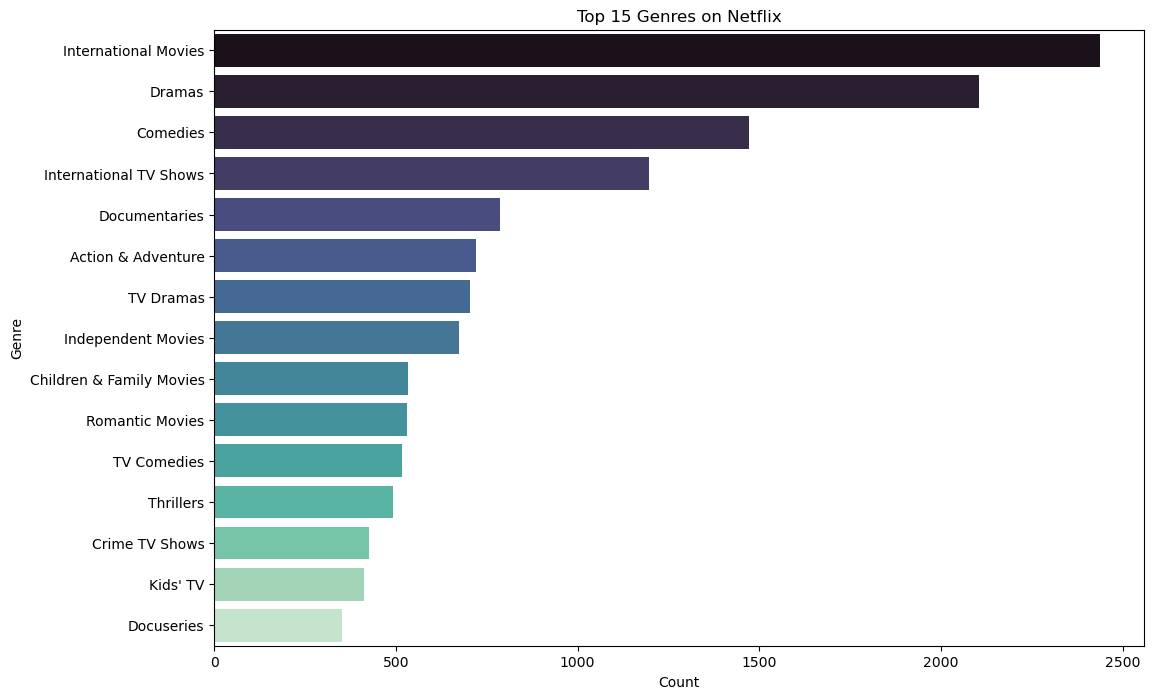

In [ ]:
# Get the top 15 genres and their counts
top_genres_counts = genres['genre'].value_counts().reset_index()
top_genres_counts.columns = ['genre', 'count'] # Rename columns for clarity

# Select only the top 15 for plotting
top_genres_counts_plot = top_genres_counts.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(y='genre', x='count', data=top_genres_counts_plot, palette='mako', hue='genre', legend=False)
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

**洞察** :“国际电影”是最常见的类型标签，凸显了 Netflix 的全球内容战略。其次是剧情片、喜剧片和动作冒险片。

#### 4.4 内容时长分布情况如何？

In [ ]:
# Separate movies and TV shows
movies_df = netflix_df[netflix_df['type'] == 'Movie'].copy()
tv_shows_df = netflix_df[netflix_df['type'] == 'TV Show'].copy()

In [ ]:
# Clean and convert duration for movies
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)

# Clean and convert duration for TV shows
tv_shows_df['seasons'] = tv_shows_df['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(int)

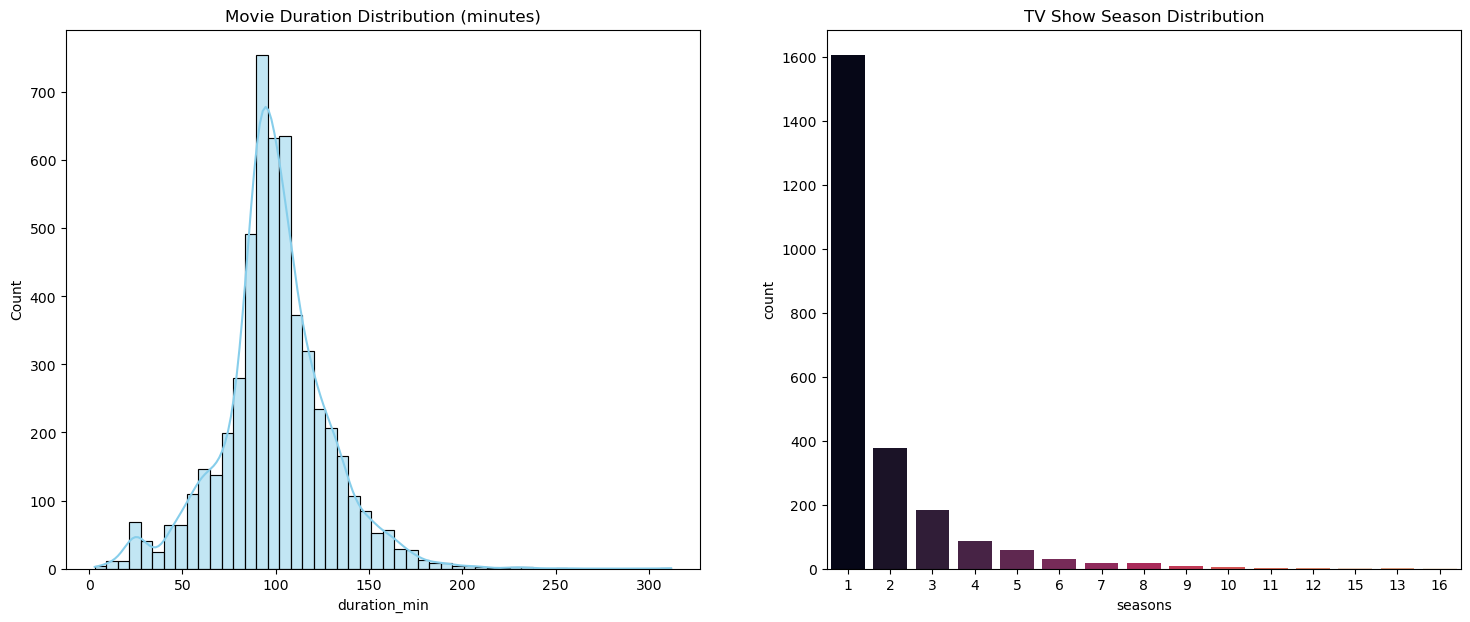

In [ ]:
# Plot the distributions
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Movie Duration Distribution
sns.histplot(ax=axes[0], data=movies_df, x='duration_min', bins=50, kde=True, color='skyblue').set_title('Movie Duration Distribution (minutes)')

# TV Show Season Distribution
sns.countplot(ax=axes[1], x='seasons', data=tv_shows_df, palette='rocket', order=tv_shows_df['seasons'].value_counts().index, hue='seasons', legend=False).set_title('TV Show Season Distribution')

plt.show()

**洞察：**

- Netflix 上的大多数电影时长在 80 到 120 分钟之间，这与故事片的标准时长相符。

- Netflix 上的绝大多数剧集都比较短，大多数只有一季。这可能反映了 Netflix 的策略是制作大量试播集，然后只续订最成功的剧集，或者专注于制作限定剧集。

#### 4.5 内容来源是什么？（地理分析）

In [ ]:
# Handle the multi-country listings similar to genres
countries = netflix_df.assign(country=netflix_df['country'].str.split(', ')).explode('country')

In [ ]:
# Get the top 15 countries and their counts
top_countries_counts = countries['country'].value_counts().reset_index()
top_countries_counts.columns = ['country', 'count'] # Rename columns for clarity

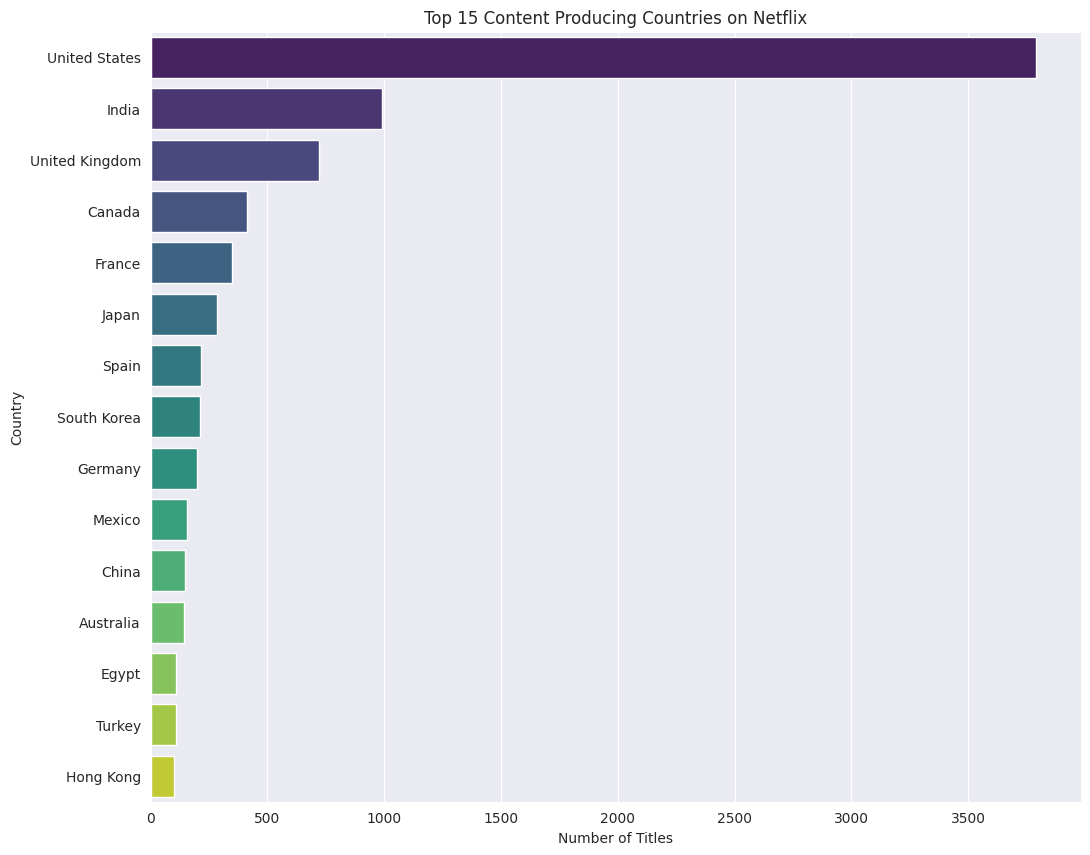

In [ ]:
# Select only the top 15 for plotting
top_countries_counts_plot = top_countries_counts.head(15)

plt.figure(figsize=(12, 10))
sns.barplot(y='country', x='count', data=top_countries_counts_plot, palette='viridis', hue='country', legend=False)
plt.title('Top 15 Content Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

**洞察：**美国是Netflix内容的最大产地，遥遥领先。然而，印度紧随其后，实力强劲，这也解释了为什么众多顶级演员都来自印度。英国、日本和韩国也是该平台的重要内容市场，凸显了其全球化的本质。

In [ ]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12


#### 4.6 What are the maturity ratings of the content?

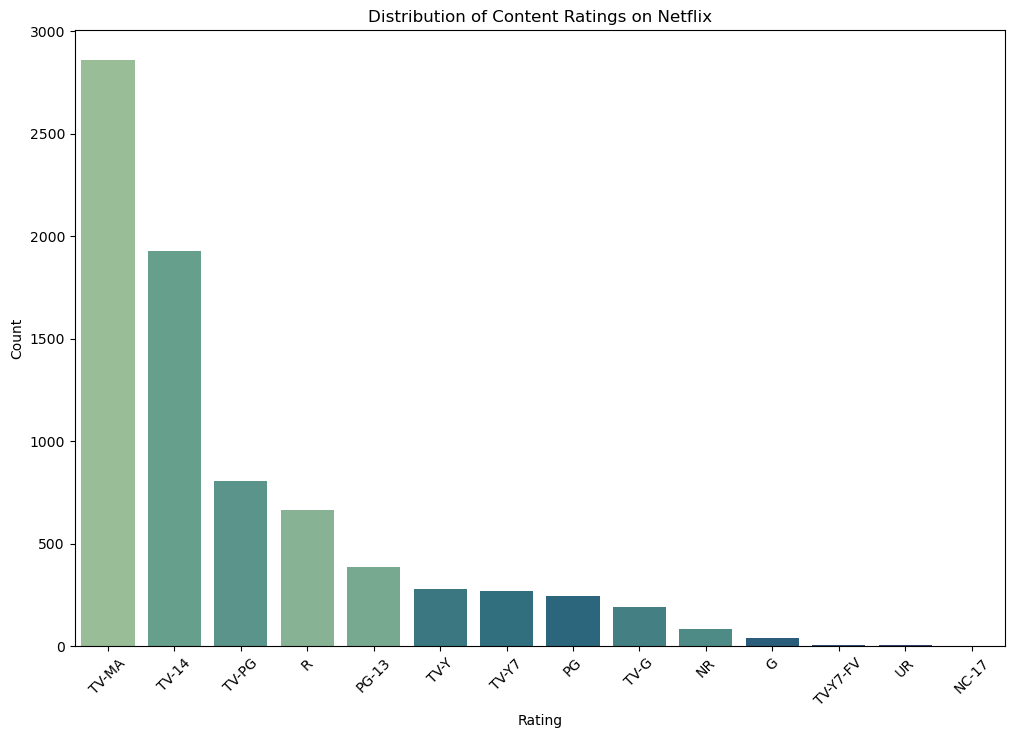

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(x='rating', data=netflix_df, order=netflix_df['rating'].value_counts().index, palette='crest', hue='rating', legend=False)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**洞察：** Netflix 的大部分内容面向成年观众，其中“TV-MA”（成人级）和“TV-14”（强烈建议家长注意）是最常见的两种评级。这表明 Netflix 更注重成年观众，而非儿童内容（“TV-G”、“TV-Y”）。

### 第五步：功能工程 - 内容新鲜度

让我们创建一个新功能，分析内容添加到 Netflix 时有多旧。这可以告诉我们他们的内容获取策略（购买经典老片还是推出原创新片）。

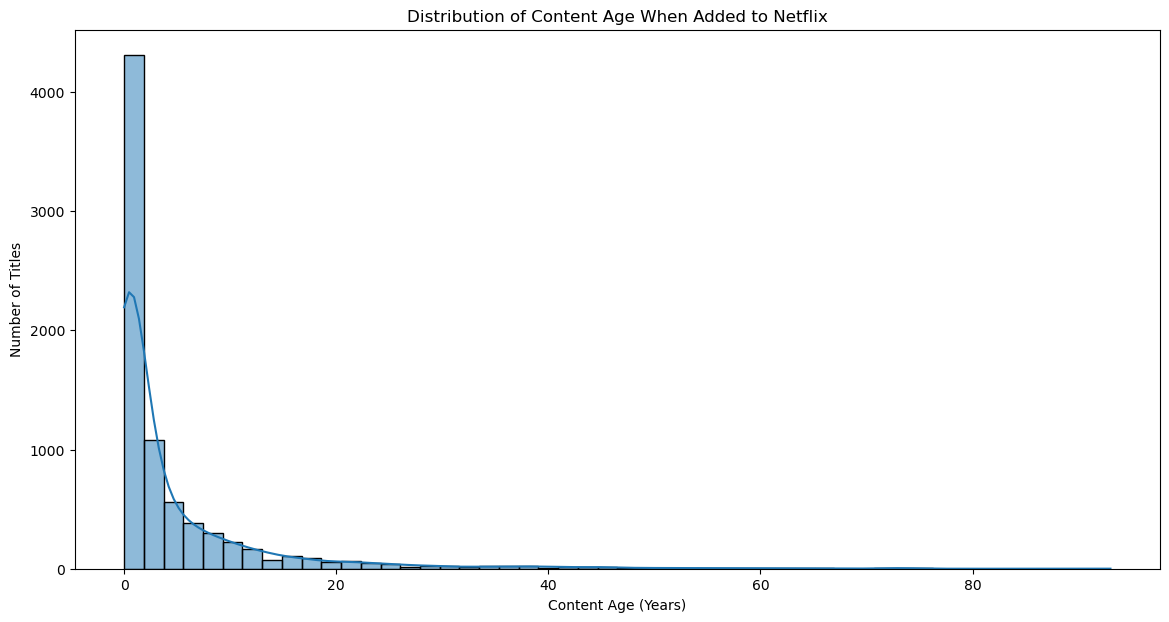

In [ ]:
# Create the 'age_on_netflix' feature
netflix_df['age_on_netflix'] = netflix_df['year_added'] - netflix_df['release_year']

# Filter out any potential errors where added_year is before release_year
content_age = netflix_df[netflix_df['age_on_netflix'] >= 0]

plt.figure(figsize=(14, 7))
sns.histplot(data=content_age, x='age_on_netflix', bins=50, kde=True)
plt.title('Distribution of Content Age When Added to Netflix')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')
plt.show()

**洞察：** 0 处的峰值显著，表明大量内容会在发布当年就被添加到新内容库中，这是“Netflix 原创内容”的典型特征。然而，该指标存在一个很长的尾部，表明 Netflix 也大力投资收购可能已有数十年历史的授权内容，从而构建了一个庞大的经典电影和剧集库。

### 第六步：更深入的多变量分析

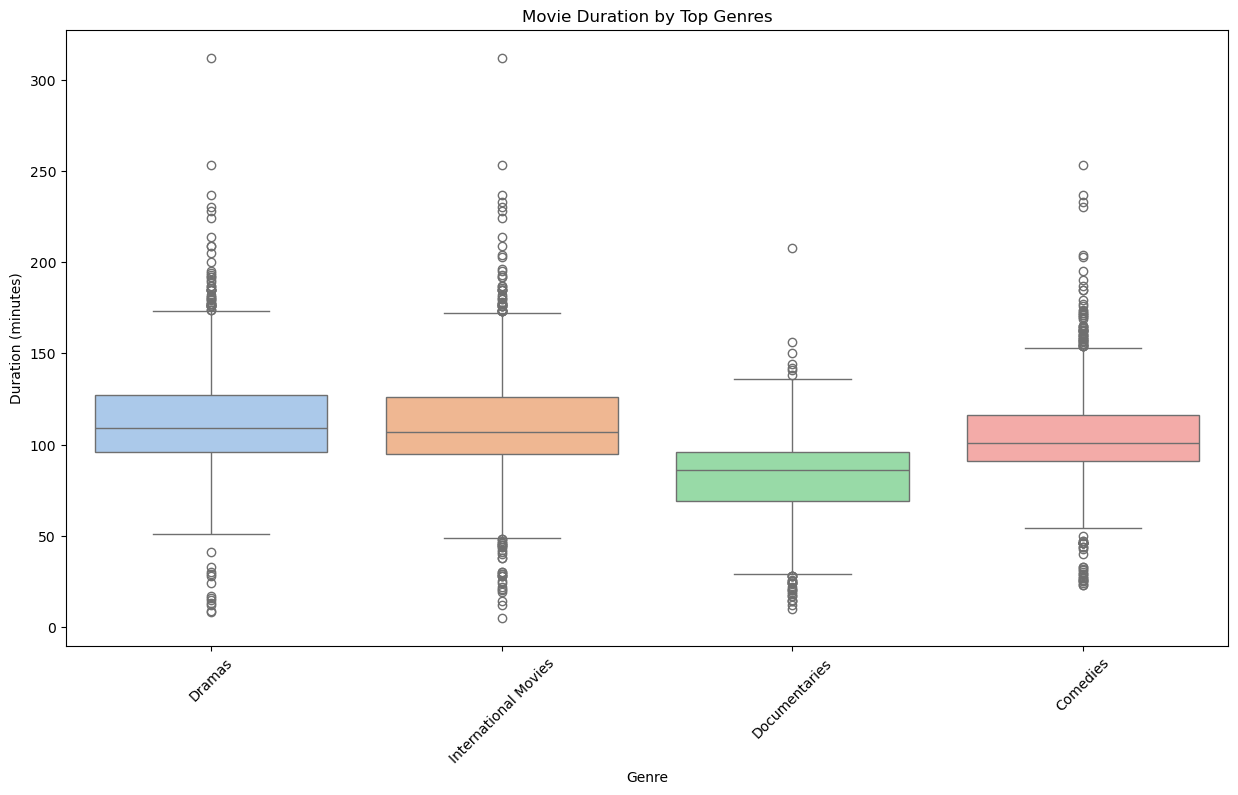

In [ ]:
# Analyze movie duration across different top genres
top_genres = genres['genre'].value_counts().index[:5]
genres_movies = genres[(genres['type'] == 'Movie') & (genres['genre'].isin(top_genres))].copy()
genres_movies['duration_min'] = genres_movies['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(15, 8))
sns.boxplot(data=genres_movies, x='genre', y='duration_min', palette='pastel', hue='genre', legend=False)
plt.title('Movie Duration by Top Genres')
plt.xlabel('Genre')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.show()

**洞察：** 虽然大多数热门类型的影片时长中位数相近（约90-100分钟），但我们仍可发现一些有趣的差异。例如，剧情片的时长范围更广，其中不乏较长的影片。国际电影的时长分布也十分广泛，反映了世界各地不同的电影制作风格。

### 第 7 步：根据内容描述生成词云

作为最后的视觉分析，让我们根据“描述”列生成词云，看看 Netflix 内容中最常见的主题和词语是什么。

0       In a future where the elite inhabit an island ...
1       After a devastating earthquake hits Mexico Cit...
2       When an army recruit is found dead, his fellow...
3       In a postapocalyptic world, rag-doll robots hi...
4       A brilliant group of students become card-coun...
                              ...                        
7782    When Lebanon's Civil War deprives Zozo of his ...
7783    A scrappy but poor boy worms his way into a ty...
7784    In this documentary, South African rapper Nast...
7785    Dessert wizard Adriano Zumbo looks for the nex...
7786    This documentary delves into the mystique behi...
Name: description, Length: 7770, dtype: object
In a future where the elite inhabit an island paradise far from the crowded slums, you get one chance to join the 3% saved from squalor. After a devastating earthquake hits Mexico City, trapped survivors from all walks of life wait to be rescued while trying desperately to stay alive. When an army recruit is found

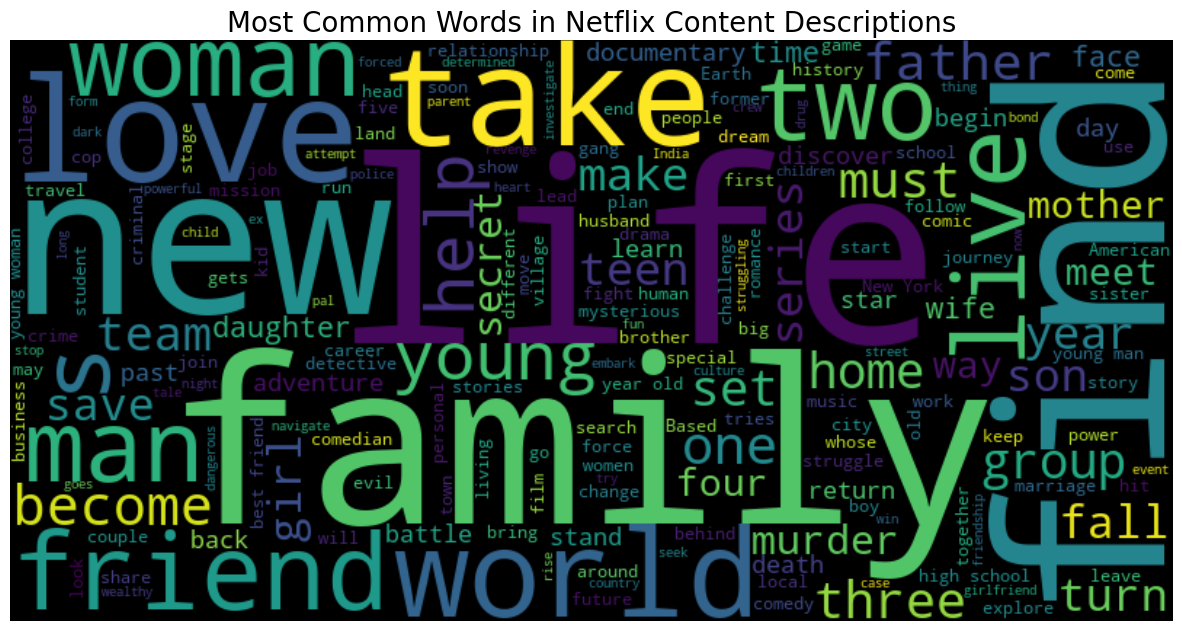

In [45]:
print(netflix_df['description'])
# Combine all descriptions into a single string
text = ' '.join(netflix_df['description'])
print(text)

# Create and generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

# Display the generated image
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud.to_image(), interpolation='bilinear')  # 或者 wordcloud.to_array()
plt.axis('off')
plt.title('Most Common Words in Netflix Content Descriptions', fontsize=20)
plt.show()

**洞察：**词云突出了常见的主题和话题。“生活”、“家庭”、“爱”、“年轻”、“朋友”和“世界”等词语频繁出现，表明大部分内容都围绕人际关系和个人经历展开。“发现”、“秘密”和“新的”等行动导向的词语也频繁出现。

### 第八步：最终结论和洞察总结

本次对 Netflix 数据集的深入探索性数据分析 (EDA) 揭示了该平台内容库的几个关键特征和策略。

**主要发现：**

1. **内容策略：** Netflix 的内容库以电影为主（约占 70%），并且在 2016 年至 2019 年间积极扩充内容。其策略是将全新原创内容（上映当年即上线）与丰富的授权老片库相结合。

2. **全球主导地位：** 虽然美国是最大的内容生产国，但该平台具有很强的国际化特色，其中印度贡献巨大。这体现在最热门的类型（“国际电影”）和最常出现的演员身上。

3. **目标受众：** 内容库主要面向成熟观众，其中“TV-MA”和“TV-14”是最常见的评级。

4. **内容形式与类型：**剧情片和喜剧片是广受欢迎的类型。大多数电影的片长都在标准的 90-120 分钟之间，而绝大多数电视剧只有一季，这表明剧集制作是一种高风险、高回报的模式。

5. **常见主题：**内容描述通常围绕着生活、家庭、爱情和探索等普世主题展开。

**局限性：**该数据集仅反映了特定时间点的情况，缺乏观看数据。因此，我们的分析侧重于内容的*供给*，而非其*需求*或受欢迎程度。尽管如此，本次探索性数据分析 (EDA) 仍然能够让我们对 Netflix 片库的构成和发展历程有一个全面而深入的了解。

### 第八步：最终结论和洞察总结

本次对 Netflix 数据集的深入探索性数据分析 (EDA) 揭示了该平台内容库的几个关键特征和策略。

**主要发现：**

1. **内容策略：** Netflix 的内容库以电影为主（约占 70%），并且在 2016 年至 2019 年间积极扩充内容。其策略是将全新原创内容（上映当年即上线）与丰富的授权老片库相结合。

2. **全球主导地位：** 虽然美国是最大的内容生产国，但该平台具有很强的国际化特色，其中印度贡献巨大。这体现在最热门的类型（“国际电影”）和最常出现的演员身上。

3. **目标受众：** 内容库主要面向成熟观众，其中“TV-MA”和“TV-14”是最常见的评级。

4. **内容形式与类型：**剧情片和喜剧片是广受欢迎的类型。大多数电影的片长都在标准的 90-120 分钟之间，而绝大多数电视剧只有一季，这表明剧集制作是一种高风险、高回报的模式。

5. **常见主题：**内容描述通常围绕着生活、家庭、爱情和探索等普世主题展开。

**局限性：**该数据集仅反映了特定时间点的情况，缺乏观看数据。因此，我们的分析侧重于内容的*供给*，而非其*需求*或受欢迎程度。尽管如此，本次探索性数据分析 (EDA) 仍然能够让我们对 Netflix 片库的构成和发展历程有一个全面而深入的了解。

# Submission Q's

* 内容分级分布随时间发生了怎样的变化？

* 内容的发布年份与其类型（电影或电视剧）之间是否存在关联？

* 我们能否根据内容的发行年份与上线 Netflix 的年份，识别出内容制作方面的任何趋势？

* 内容描述中最常见的词组或短语有哪些？

* Netflix 上最知名的导演有哪些？

### You can connect with me on [Linkedin](https://www.linkedin.com/in/harshvardhan-singh-350262178/) if you like the content